###Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12,6)

###Load dataset

In [ ]:
df = pd.read_csv('analysis data.csv')

###Dataset overview

In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.head()

Rows : 82365
Columns : 39


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_height_cm,product_width_cm,product_category_name_english,purchase_year,purchase_month,purchase_quarter,purchase_day,delivery_days,delivery_delay,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,20.0,Unknown,2017,10,4,2,8.0,-8.0,On Time
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,20.0,Unknown,2017,10,4,2,8.0,-8.0,On Time
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,20.0,Unknown,2017,10,4,2,8.0,-8.0,On Time
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,13.0,19.0,perfumery,2018,7,3,24,13.0,-6.0,On Time
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.0,21.0,auto,2018,8,3,8,9.0,-18.0,On Time


###Check Required Columns

In [ ]:
required_columns = [
    'product_category_name_english',
    'order_id',
    'customer_unique_id',
    'customer_state',
    'revenue'
]

print(df[required_columns].head())

  product_category_name_english                          order_id  \
0                       Unknown  e481f51cbdc54678b7cc49136f2d6af7   
1                       Unknown  e481f51cbdc54678b7cc49136f2d6af7   
2                       Unknown  e481f51cbdc54678b7cc49136f2d6af7   
3                     perfumery  53cdb2fc8bc7dce0b6741e2150273451   
4                          auto  47770eb9100c2d0c44946d9cf07ec65d   

                 customer_unique_id customer_state  revenue  
0  7c396fd4830fd04220f754e42b4e5bff             SP      0.0  
1  7c396fd4830fd04220f754e42b4e5bff             SP      0.0  
2  7c396fd4830fd04220f754e42b4e5bff             SP      0.0  
3  af07308b275d755c9edb36a90c618231             BA    118.7  
4  3a653a41f6f9fc3d2a113cf8398680e8             GO    159.9  


Top 10 selling Categories

In [ ]:
top10_selling = (
    df.groupby('product_category_name_english')
      ['order_id']
      .nunique()
      .reset_index()
      .rename(columns={'order_id':'Orders'})
      .sort_values(
          'Orders',
          ascending=False
      )
      .head(10)
)

top10_selling

,product_category_name_english,Orders
0,Unknown,14600
8,bed_bath_table,5473
44,health_beauty,5089
66,sports_leisure,4454
16,computers_accessories,3880
40,furniture_decor,3731
50,housewares,3447
71,watches_gifts,3287
69,telephony,2430
6,auto,2260


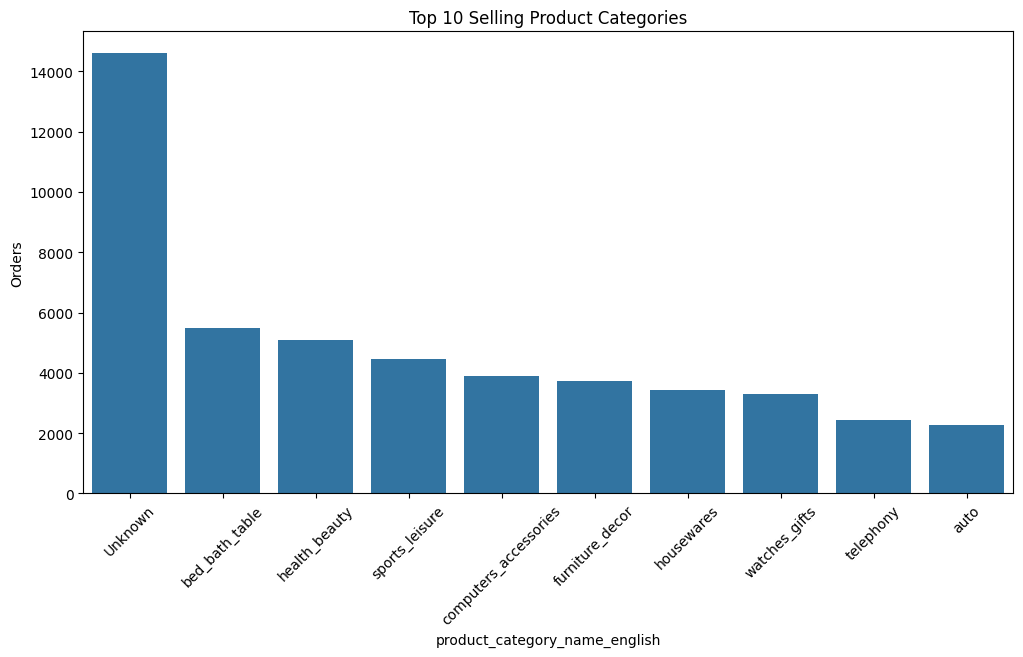

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_selling,
    x='product_category_name_english',
    y='Orders'
)

plt.xticks(rotation=45)

plt.title(
    'Top 10 Selling Product Categories'
)

plt.show()

###Bottom 10 selling Categories

In [ ]:
bottom10_selling = (
    df.groupby('product_category_name_english')
      ['order_id']
      .nunique()
      .reset_index()
      .rename(columns={'order_id':'Orders'})
      .sort_values('Orders')
      .head(10)
)

bottom10_selling

,product_category_name_english,Orders
62,security_and_services,2
30,fashion_childrens_clothes,6
53,la_cuisine,7
12,cds_dvds_musicals,8
24,diapers_and_hygiene,13
33,fashion_sport,15
47,home_comfort_2,16
4,arts_and_craftmanship,16
36,flowers,17
28,fashio_female_clothing,20


###TOP 10 Revenue Categories

In [ ]:
top10_revenue = (
    df.groupby('product_category_name_english')
      ['revenue']
      .sum()
      .reset_index()
      .sort_values(
          'revenue',
          ascending=False
      )
      .head(10)
)

top10_revenue

,product_category_name_english,revenue
71,watches_gifts,743296.92
44,health_beauty,737409.81
8,bed_bath_table,625785.69
66,sports_leisure,590918.46
16,computers_accessories,540672.77
40,furniture_decor,440672.31
50,housewares,392340.16
21,cool_stuff,381264.17
6,auto,360329.79
43,garden_tools,292393.44


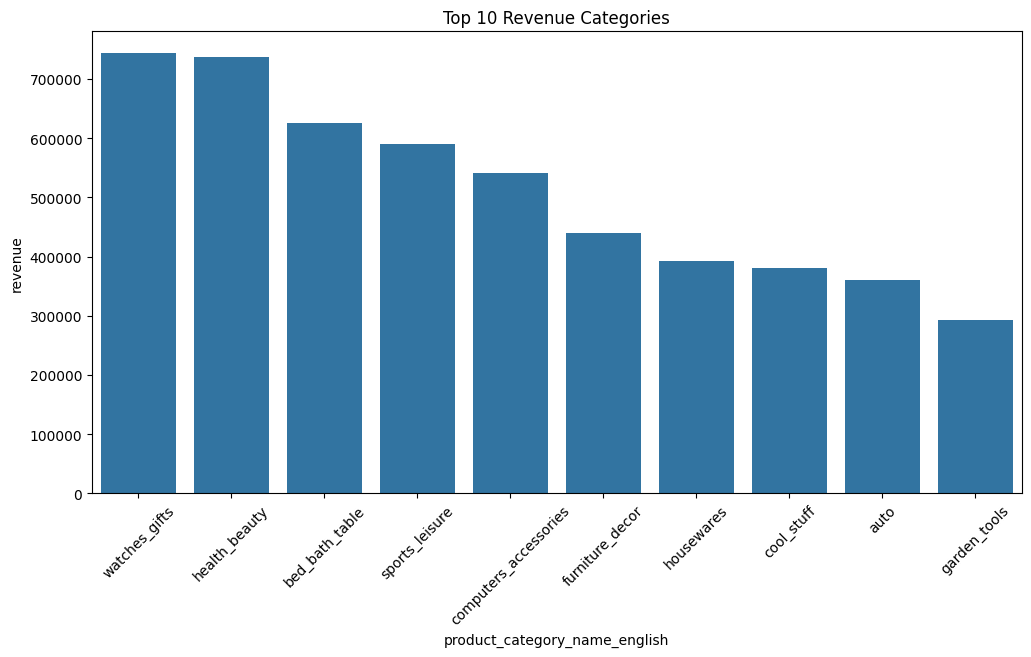

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_revenue,
    x='product_category_name_english',
    y='revenue'
)

plt.xticks(rotation=45)

plt.title(
    'Top 10 Revenue Categories'
)

plt.show()

###Bottom 10 Revenue Categories

In [ ]:
bottom10_revenue = (
    df.groupby('product_category_name_english')
      ['revenue']
      .sum()
      .reset_index()
      .sort_values('revenue')
      .head(10)
)

bottom10_revenue

,product_category_name_english,revenue
62,security_and_services,283.29
30,fashion_childrens_clothes,419.86
12,cds_dvds_musicals,465.00
47,home_comfort_2,618.37
36,flowers,673.55
24,diapers_and_hygiene,864.79
33,fashion_sport,1034.52
4,arts_and_craftmanship,1195.34
53,la_cuisine,1378.98
28,fashio_female_clothing,1568.17


###top categories by customers

In [ ]:
top_customer_categories = (
    df.groupby('product_category_name_english')
      ['customer_unique_id']
      .nunique()
      .reset_index()
      .rename(
          columns={
              'customer_unique_id':
              'Unique_Customers'
          }
      )
      .sort_values(
          'Unique_Customers',
          ascending=False
      )
      .head(10)
)

top_customer_categories

,product_category_name_english,Unique_Customers
0,Unknown,14500
8,bed_bath_table,5390
44,health_beauty,5024
66,sports_leisure,4383
16,computers_accessories,3837
40,furniture_decor,3684
50,housewares,3423
71,watches_gifts,3267
69,telephony,2416
6,auto,2240


###Top categories by Repeat purchase

In [ ]:
repeat_purchase = (
    df.groupby(
        'product_category_name_english'
    )
    ['customer_unique_id']
    .count()
    .reset_index()
    .rename(
        columns={
            'customer_unique_id':
            'Purchases'
        }
    )
    .sort_values(
        'Purchases',
        ascending=False
    )
    .head(10)
)

repeat_purchase

,product_category_name_english,Purchases
0,Unknown,15343
8,bed_bath_table,6725
44,health_beauty,5749
66,sports_leisure,5156
40,furniture_decor,5029
16,computers_accessories,4653
50,housewares,4282
71,watches_gifts,3649
69,telephony,2750
43,garden_tools,2712


###product Demand by State

In [ ]:
top_products = (
    df['product_category_name_english']
    .value_counts()
    .head(10)
    .index
)

heatmap_df = df[
    df['product_category_name_english']
    .isin(top_products)
]

In [ ]:
product_state = pd.crosstab(
    heatmap_df['customer_state'],
    heatmap_df[
        'product_category_name_english'
    ]
)

product_state

product_category_name_english,Unknown,bed_bath_table,computers_accessories,furniture_decor,garden_tools,health_beauty,housewares,sports_leisure,telephony,watches_gifts
customer_state,,,,,,,,,,
AC,16,3,4,5,0,5,3,8,2,2
AL,56,12,24,18,11,38,6,20,18,23
AM,23,4,8,2,2,15,4,5,8,3
AP,9,6,5,3,1,6,3,5,3,2
BA,518,174,157,159,106,237,102,170,166,154
CE,205,54,71,50,30,106,25,60,50,84
DF,312,114,97,100,40,146,88,122,68,84
ES,293,137,90,84,51,96,69,93,65,99
GO,314,144,80,75,65,128,72,104,75,109


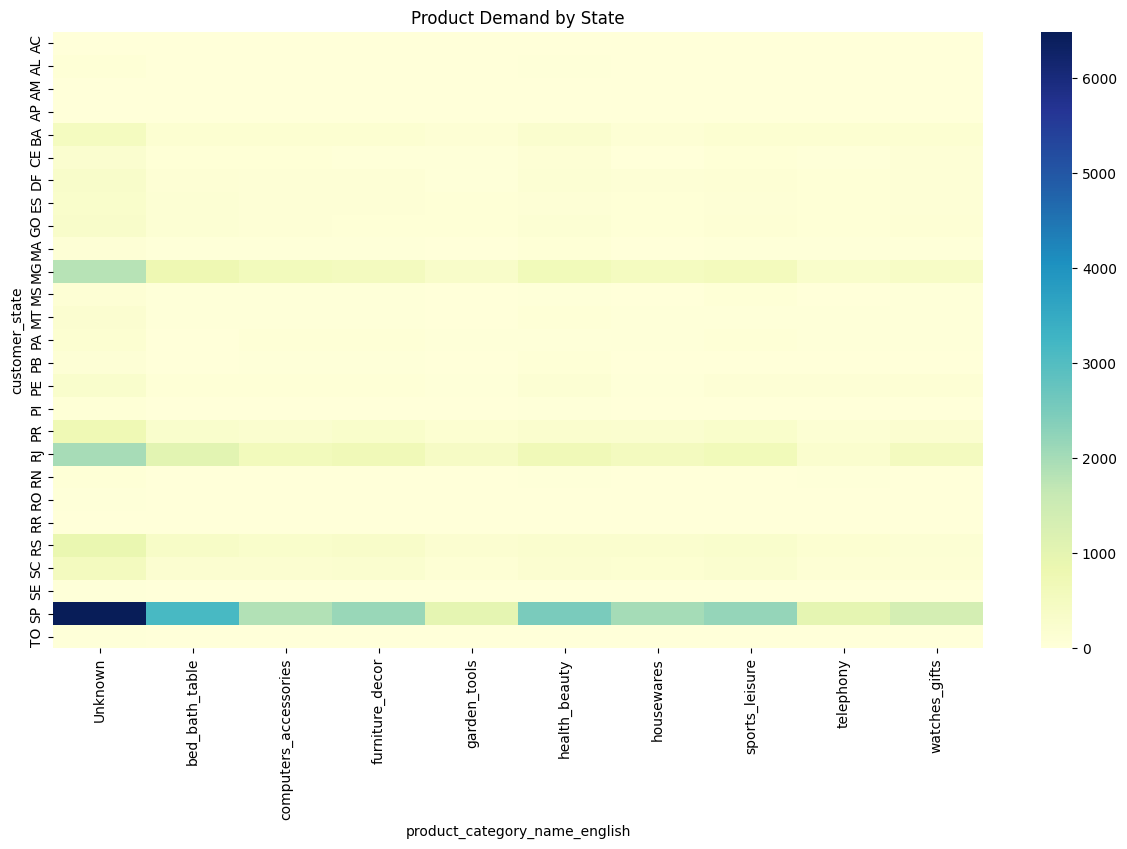

In [ ]:
plt.figure(figsize=(15,8))

sns.heatmap(
    product_state,
    cmap='YlGnBu'
)

plt.title(
    'Product Demand by State'
)

plt.show()

###load RFM file

In [ ]:
rfm = pd.read_csv(
    'RFM_Customer_Segmentation.csv'
)

###Merge product data with RFM

In [ ]:
merged_df = df.merge(
    rfm[
        ['CustomerID',
         'Segment']
    ],
    left_on='customer_unique_id',
    right_on='CustomerID',
    how='left'
)

###Champions' Favorite Products

In [ ]:
champions_products = (
    merged_df[
        merged_df['Segment']
        == 'Champions'
    ]
    ['product_category_name_english']
    .value_counts()
    .reset_index()
)

champions_products.columns = [
    'Product_Category',
    'Purchases'
]

champions_products.head(10)

,Product_Category,Purchases
0,health_beauty,65
1,watches_gifts,64
2,housewares,53
3,furniture_decor,44
4,sports_leisure,41
5,bed_bath_table,39
6,computers_accessories,38
7,cool_stuff,30
8,auto,19
9,toys,18


###Loyal Customers' Favorite Products

In [ ]:
loyal_products = (
    merged_df[
        merged_df['Segment']
        == 'Loyal Customers'
    ]
    ['product_category_name_english']
    .value_counts()
    .reset_index()
)

loyal_products.columns = [
    'Product_Category',
    'Purchases'
]

loyal_products.head(10)

,Product_Category,Purchases
0,Unknown,319
1,health_beauty,89
2,bed_bath_table,81
3,computers_accessories,77
4,sports_leisure,75
5,furniture_decor,63
6,telephony,55
7,housewares,50
8,watches_gifts,43
9,electronics,38


###Product vs Customer Segment Heatmap

In [ ]:
segment_product = pd.crosstab(
    merged_df['Segment'],
    merged_df[
        'product_category_name_english'
    ]
)

segment_product

product_category_name_english,Unknown,agro_industry_and_commerce,air_conditioning,art,audio,auto,baby,bed_bath_table,books_general_interest,books_technical,...,pet_shop,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,watches_gifts
Segment,,,,,,,,,,,,,,,,,,,,,
At Risk,369,0,5,2,3,37,45,149,5,1,...,25,0,8,0,129,23,1,69,77,47
Champions,9,0,2,3,0,19,15,39,2,0,...,7,0,1,0,41,15,0,6,18,64
Lost Customers,218,0,0,0,0,7,4,14,1,0,...,2,0,1,0,18,3,0,30,7,6
Loyal Customers,319,4,0,3,1,37,23,81,5,3,...,16,2,8,0,75,30,2,55,22,43
Need Attention,312,0,2,4,10,63,63,217,10,4,...,40,2,11,0,167,42,1,79,76,107
Potential Loyalists,209,1,1,0,9,54,33,102,3,5,...,26,0,7,2,72,21,0,35,22,62


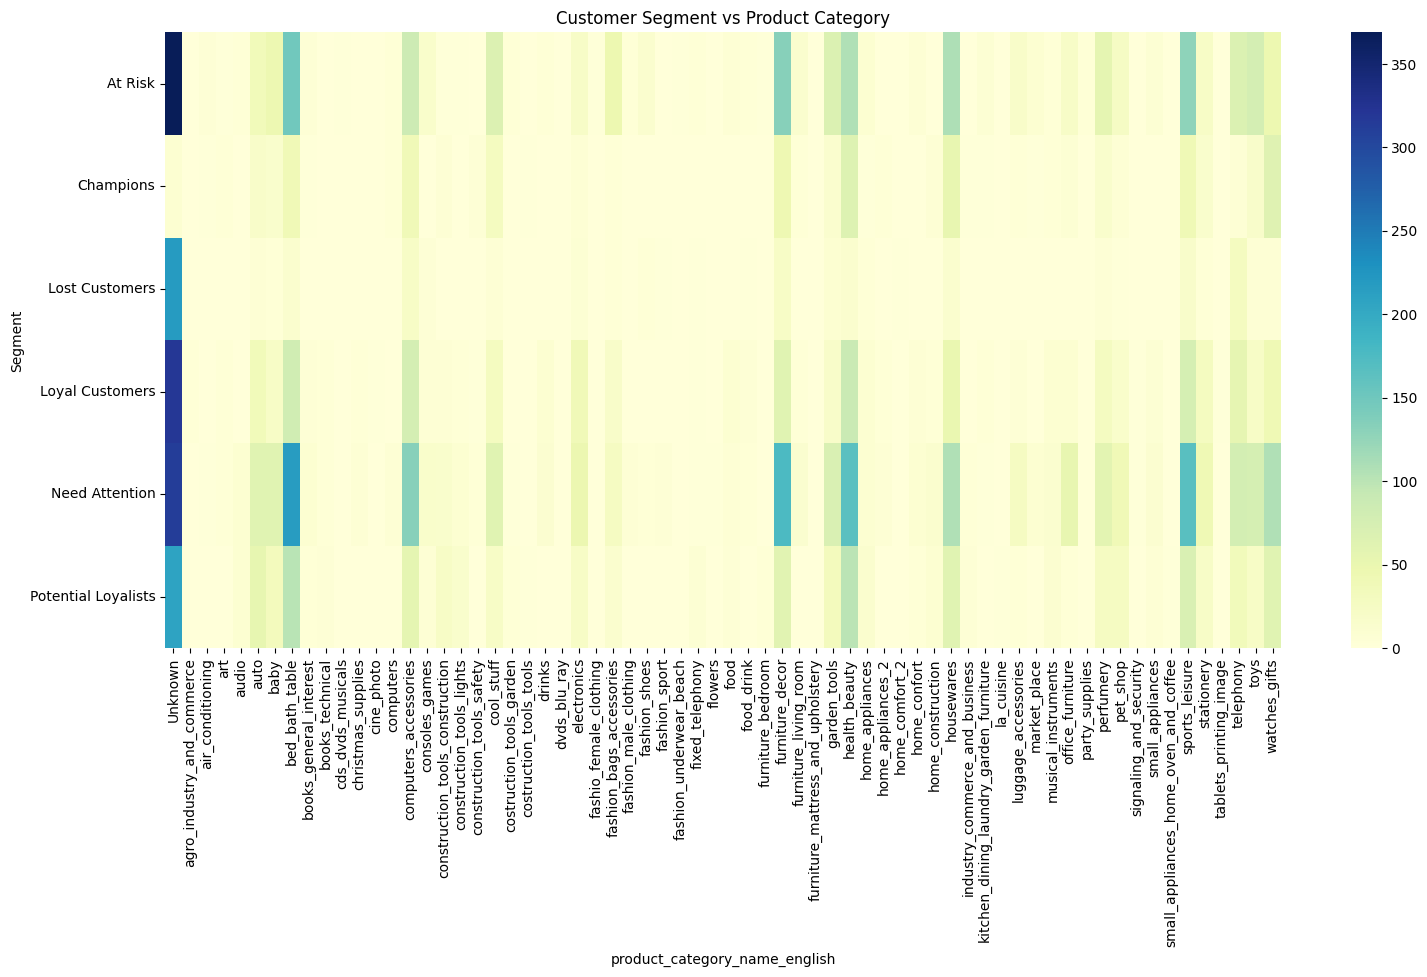

In [ ]:
plt.figure(figsize=(18,8))

sns.heatmap(
    segment_product,
    cmap='YlGnBu'
)

plt.title(
    'Customer Segment vs Product Category'
)

plt.show()